EXPLORATORY DATA ANALYSIS ON RETAIL SALES DATA

[STEP 1] Loading Dataset...
Dataset loaded successfully!!
Rows: 1000
Columns: 9
Column Names: ['Transaction_ID', 'Date', 'Customer_ID', 'Gender', 'Age', 'Product_Category', 'Quantity', 'Price_per_Unit', 'Total_Amount']
   Transaction_ID        Date Customer_ID  Gender  Age Product_Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price_per_Unit  Total_Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

STEP-02 Data Clea

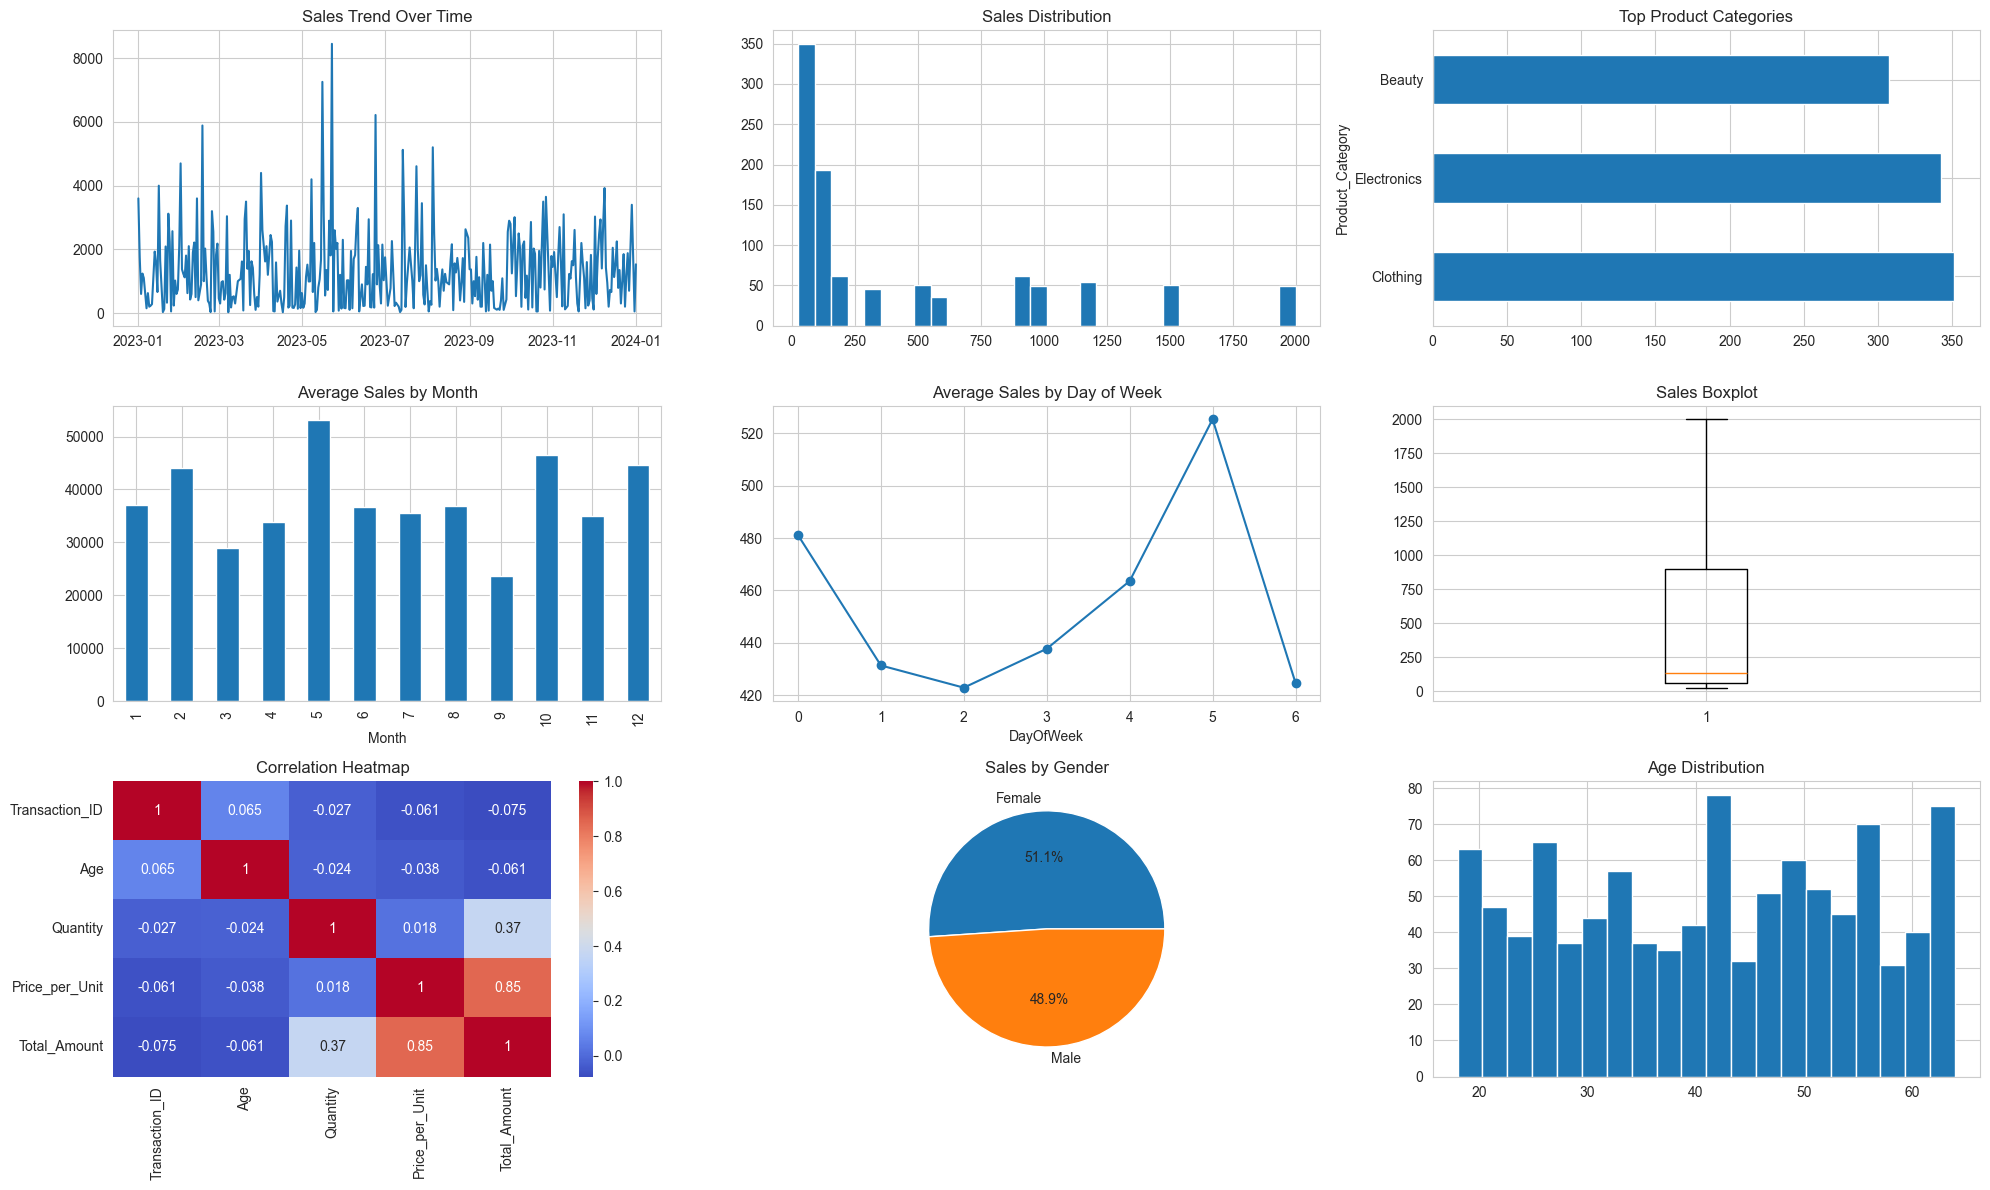


STEP-07 Insights and Recommendations
Total Sales: 456,000.00
Average Transaction Value: 456.00
Best Performing Month: 5
Worst Performing Month: 9
Most Popular Product Category: Clothing

RECOMMENDATIONS:
1. Increase inventory during peak months
2. Focus marketing on top categories
3. Use promotions during low-sales periods
4. Apply demographic-based targeting

EDA COMPLETED SUCCESSFULLY!!


In [10]:
# ============================================================
# EDA on Retail Sales Data - Oasis Infobyte Internship
# Project:Exploratory Data Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*70)
print("EXPLORATORY DATA ANALYSIS ON RETAIL SALES DATA")
print("="*70)

# ============================================================
# STEP 1: DATA LOADING
# ============================================================
print("\n[STEP 1] Loading Dataset...")

df = pd.read_csv("retail_sales_dataset.csv")

# STANDARDIZE COLUMN NAMES (CRITICAL FIX)
df.columns = df.columns.str.replace(' ', '_')

print("Dataset loaded successfully!!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column Names:", list(df.columns))
print(df.head())

# Define sales column ONCE
sales_col = 'Total_Amount'

# ============================================================
# STEP 2: DATA CLEANING
# ============================================================
print("\nSTEP-02 Data Cleaning...")

print("\nMissing Values:")
print(df.isnull().sum())

df.dropna(inplace=True)

duplicates = df.duplicated().sum()
if duplicates > 0:
    df.drop_duplicates(inplace=True)

print("✓ Missing values and duplicates handled")

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    print("✓ Date column converted")

# ============================================================
# STEP 3: DESCRIPTIVE STATISTICS
# ============================================================
print("\nSTEP-03 Descriptive Statistics...")

print(df.info())
print(df.describe())

numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    print(f"\n{col}")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Std Dev: {df[col].std():.2f}")
    print(f"Min: {df[col].min():.2f}")
    print(f"Max: {df[col].max():.2f}")

# ============================================================
# STEP 4: TIME SERIES ANALYSIS
# ============================================================
print("\nSTEP-04 Time Series Analysis...")

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

monthly_sales = df.groupby('Month')[sales_col].sum()
print(monthly_sales.describe())

# ============================================================
# STEP 5: CUSTOMER & PRODUCT ANALYSIS
# ============================================================
print("\nSTEP-05 Customer and Product Analysis...")

print("\nSales by Product Category:")
print(df.groupby('Product_Category')[sales_col].agg(['sum','mean','count']))

print("\nSales by Gender:")
print(df.groupby('Gender')[sales_col].agg(['sum','mean','count']))

print("\nCustomer Age Summary:")
print(df['Age'].describe())

# ============================================================
# STEP 6: VISUALIZATION
# ============================================================
print("\nSTEP-06 Creating Visualizations...")

fig = plt.figure(figsize=(20, 12))

# Plot 1: Sales Trend Over Time
ax1 = plt.subplot(3,3,1)
daily_sales = df.groupby('Date')[sales_col].sum()
ax1.plot(daily_sales.index, daily_sales.values)
ax1.set_title("Sales Trend Over Time")

# Plot 2: Sales Distribution
ax2 = plt.subplot(3,3,2)
ax2.hist(df[sales_col], bins=30)
ax2.set_title("Sales Distribution")

# Plot 3: Top Categories
ax3 = plt.subplot(3,3,3)
df['Product_Category'].value_counts().head(10).plot(kind='barh', ax=ax3)
ax3.set_title("Top Product Categories")

# Plot 4: Avg Sales by Month
ax4 = plt.subplot(3,3,4)
monthly_sales.plot(kind='bar', ax=ax4)
ax4.set_title("Average Sales by Month")

# Plot 5: Avg Sales by Day of Week
ax5 = plt.subplot(3,3,5)
df.groupby('DayOfWeek')[sales_col].mean().plot(marker='o', ax=ax5)
ax5.set_title("Average Sales by Day of Week")

# Plot 6: Boxplot
ax6 = plt.subplot(3,3,6)
ax6.boxplot(df[sales_col])
ax6.set_title("Sales Boxplot")

# Plot 7: Correlation Heatmap
ax7 = plt.subplot(3,3,7)
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', ax=ax7)
ax7.set_title("Correlation Heatmap")

# Plot 8: Sales by Gender
ax8 = plt.subplot(3,3,8)
df.groupby('Gender')[sales_col].sum().plot(kind='pie', autopct='%1.1f%%', ax=ax8)
ax8.set_ylabel("")
ax8.set_title("Sales by Gender")

# Plot 9: Age Distribution
ax9 = plt.subplot(3,3,9)
ax9.hist(df['Age'], bins=20)
ax9.set_title("Age Distribution")

plt.tight_layout()
plt.savefig("retail_sales_eda.png", dpi=300)
plt.show()

# ============================================================
# STEP 7: INSIGHTS & RECOMMENDATIONS
# ============================================================
print("\nSTEP-07 Insights and Recommendations")

print(f"Total Sales: {df[sales_col].sum():,.2f}")
print(f"Average Transaction Value: {df[sales_col].mean():.2f}")

best_month = df.groupby('Month')[sales_col].sum().idxmax()
worst_month = df.groupby('Month')[sales_col].sum().idxmin()

print(f"Best Performing Month: {best_month}")
print(f"Worst Performing Month: {worst_month}")

top_category = df['Product_Category'].value_counts().idxmax()
print(f"Most Popular Product Category: {top_category}")

print("\nRECOMMENDATIONS:")
print("1. Increase inventory during peak months")
print("2. Focus marketing on top categories")
print("3. Use promotions during low-sales periods")
print("4. Apply demographic-based targeting")

print("\nEDA COMPLETED SUCCESSFULLY!!")
